# Generating Markov Plots

In [18]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
import random
import networkx as nx
import gurobipy as gp
from gurobipy import Model, GRB, quicksum
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import functions as fn
import statistics
import math
import re 

In [22]:
# Import the graph data for the Markov graphs (including solution times), 
# the same method can be applied for the Erdos-Renyi pickle file with or without the aggregate constraint formulations
df = pd.read_pickle("Markov_graph_data.pkl")


In [26]:
solution_time_cols = [col for col in df.columns if col.endswith("_solution_times")]

# Find the fastest solution time across all methods for each graph
df["min_solution_time"] = df[solution_time_cols].min(axis=1)

# Column (method) that produced the minimum
df["best_method"] = (
    df[solution_time_cols]
    .idxmin(axis=1)
    .str.replace("_solution_times", "", regex=False)
)

# Create Performance Ratio columns
for col in solution_time_cols:
    ratio_col = col.replace("_solution_times", "_solution_time_ratio")
    df[ratio_col] = df[col] / df["min_solution_time"]


num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)





In [33]:
# Compute Empirical Edge Probability for each graph

df["num_edges"] = df["graph matrices"].apply(lambda A: np.triu(A, 1).sum())
df["p_hat"] = 2* df["num_edges"] / (df["N"] * (df["N"] - 1))




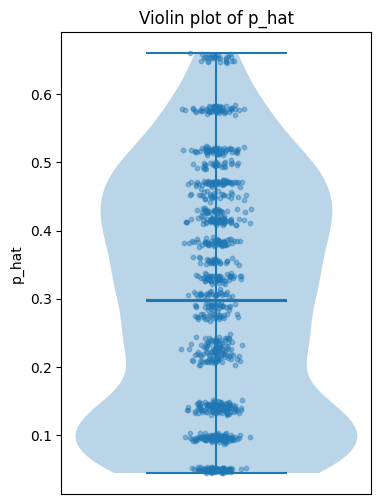

In [32]:
# Plot the empirical edge density (p_hat) distributions
x = df["p_hat"].dropna()

plt.figure(figsize=(4, 6))
plt.violinplot(x, showmeans=True, showmedians=True)

# add points with a tiny horizontal jitter
jitter = np.random.normal(1, 0.02, size=len(x))
plt.scatter(jitter, x, alpha=0.4, s=10)

plt.ylabel("p_hat")
plt.title("Violin plot of p_hat")
plt.xticks([])
plt.show()



## Plot Aggregate Performance Profile

Found 9 solvers.
Using 1080 valid problems.


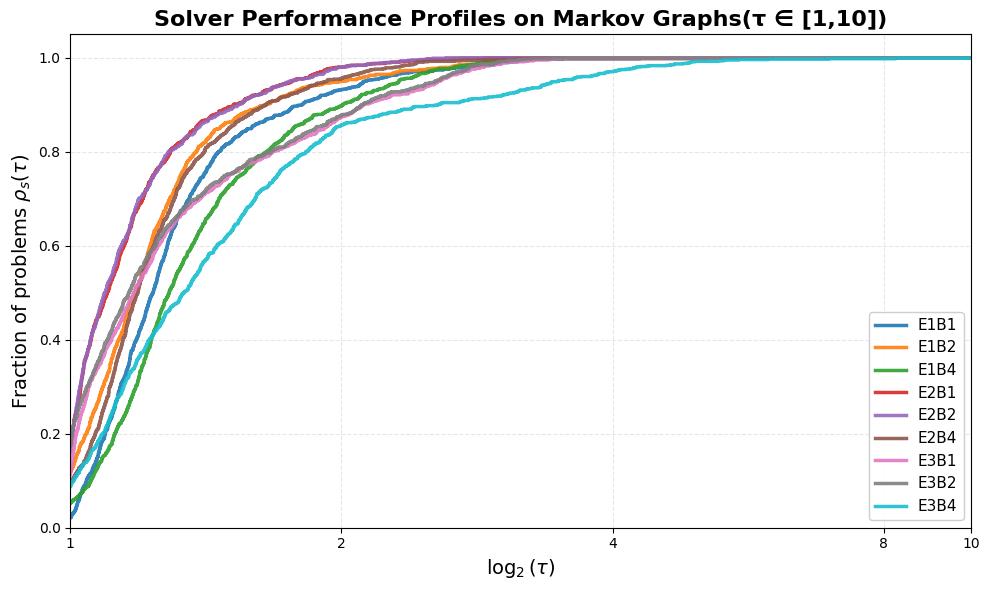

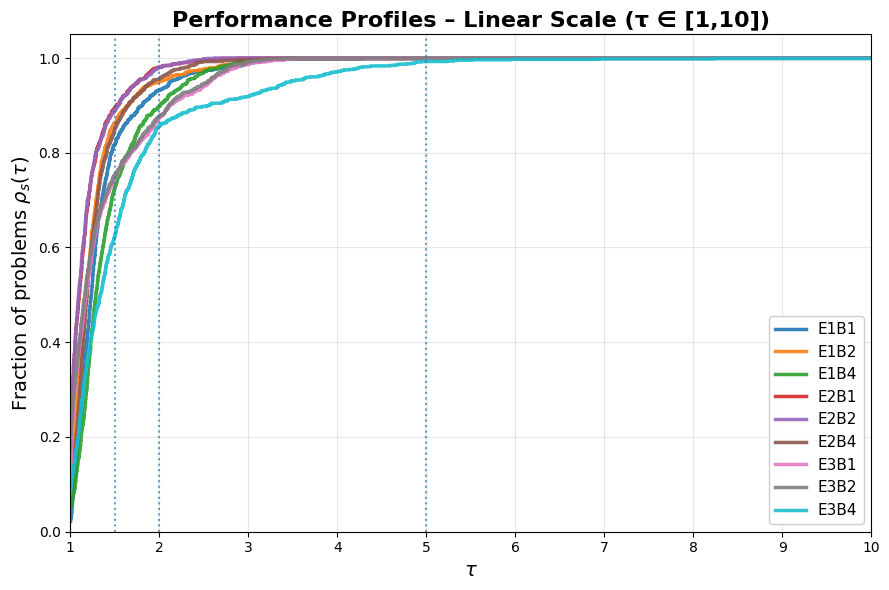

In [34]:
rel_cols = [
    col for col in df.columns
    if col.endswith("_solution_time_ratio")
]

if not rel_cols:
    raise ValueError("No *_solution_time_ratio columns found.")

def solver_sort_key(col):
    match = re.search(r"E(\d+)B(\d+)", col)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    return (999, 999)

rel_cols = sorted(rel_cols, key=solver_sort_key)

print(f"Found {len(rel_cols)} solvers.")

# ------------------------------------------------------------------
# Build ratio matrix
# ------------------------------------------------------------------
ratios = df[rel_cols].apply(pd.to_numeric, errors="coerce").values

valid_mask = (
    ~np.any(np.isnan(ratios), axis=1) &
    ~np.any(ratios <= 0, axis=1)
)

ratios = ratios[valid_mask]
n_problems = ratios.shape[0]

print(f"Using {n_problems} valid problems.")

# ------------------------------------------------------------------
# Dolan–Moré performance profile
# ------------------------------------------------------------------
def performance_profile(ratios, tau_max=10.0, n_pts=2000):
    tau = np.logspace(0, np.log10(tau_max), n_pts)
    rho = np.mean(ratios[:, :, np.newaxis] <= tau, axis=0)
    return tau, rho

tau_log, rho_log = performance_profile(ratios, tau_max=10)

solver_labels = [
    col.replace("_solution_time_ratio", "")
    for col in rel_cols
]


# Set colour pallete - since we have discarded E1B3 and E2B3 we have 9 possible formulations for Markov Graphs
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c',
    '#d62728', '#9467bd', '#8c564b',
    '#e377c2', '#7f7f7f',
    '#17becf'
]


# 1. Log₂ performance profile (τ ∈ [1,10])

plt.figure(figsize=(10, 6))

for i in range(len(rel_cols)):
    plt.step(
        np.log2(tau_log),
        rho_log[i, :],
        where="post",
        label=solver_labels[i],
        linewidth=2.5,
        color=colors[i % len(colors)],
        alpha=0.9
    )

plt.xlabel(r"$\log_2(\tau)$", fontsize=14)
plt.ylabel(r"Fraction of problems $\rho_s(\tau)$", fontsize=14)
plt.title("Solver Performance Profiles on Markov Graphs(τ ∈ [1,10])",
          fontsize=16, fontweight="bold")

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.xlim(0, np.log2(10))
plt.ylim(0, 1.05)

# Proper tick placement for tau in [1,10]
tau_ticks = [1, 2, 4, 8, 10]
plt.xticks(
    [np.log2(t) for t in tau_ticks],
    [str(t) for t in tau_ticks]
)

plt.legend(fontsize=11, loc="lower right", framealpha=0.95)
plt.tight_layout()
plt.savefig("perf_profile_log2.pdf", dpi=300, bbox_inches="tight")
plt.show()



# 2. Linear scale version (τ ∈ [1,10])

tau_lin = np.linspace(1, 10, 2000)
rho_lin = np.mean(ratios[:, :, np.newaxis] <= tau_lin, axis=0)

plt.figure(figsize=(9, 6))

for i in range(len(rel_cols)):
    plt.step(
        tau_lin,
        rho_lin[i, :],
        where="post",
        label=solver_labels[i],
        linewidth=2.5,
        color=colors[i % len(colors)],
        alpha=0.9
    )

plt.axvline(x=1.5, linestyle=":", alpha=0.7)
plt.axvline(x=2, linestyle=":", alpha=0.7)
plt.axvline(x=5, linestyle=":", alpha=0.7)

plt.xlabel(r"$\tau$", fontsize=14)
plt.ylabel(r"Fraction of problems $\rho_s(\tau)$", fontsize=14)
plt.title("Performance Profiles – Linear Scale (τ ∈ [1,10])",
          fontsize=16, fontweight="bold")

plt.grid(True, alpha=0.3)
plt.xlim(1, 10)
plt.ylim(0, 1.05)
plt.legend(fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.savefig("perf_profile_linear.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Summary statistics, if required

# print("\n" + "="*50)
# print("PERFORMANCE PROFILE STATISTICS")
# print("="*50)

# worst_ratios_per_problem = np.max(ratios, axis=1)
# is_worst = ratios == worst_ratios_per_problem[:, np.newaxis]
# worst_counts = np.sum(is_worst, axis=0)

# for i in range(len(rel_cols)):
#     ratios_solver = ratios[:, i]

#     best_count = np.sum(ratios_solver == 1)
#     worst_count = worst_counts[i]

#     eff_1_1 = np.mean(ratios_solver <= 1.1)
#     eff_1_5 = np.mean(ratios_solver <= 1.5)
#     eff_2 = np.mean(ratios_solver <= 2)
#     robustness = np.mean(ratios_solver <= 10)

#     print(f"\n{solver_labels[i]}:")
#     print(f"  - Best on {best_count}/{n_problems} ({100*best_count/n_problems:.1f}%)")
#     print(f"  - Worst on {worst_count}/{n_problems} ({100*worst_count/n_problems:.1f}%)")
#     print(f"  - Efficiency (τ ≤ 1.1): {100*eff_1_1:.1f}%")
#     print(f"  - Efficiency (τ ≤ 1.5): {100*eff_1_5:.1f}%")
#     print(f"  - Efficiency (τ ≤ 2.0): {100*eff_2:.1f}%")
#     print(f"  - Robustness (τ ≤ 10): {100*robustness:.1f}%")
#     print(f"  - Worst ratio observed: {np.max(ratios_solver):.2f}")

## Bucketed Performance Profiles

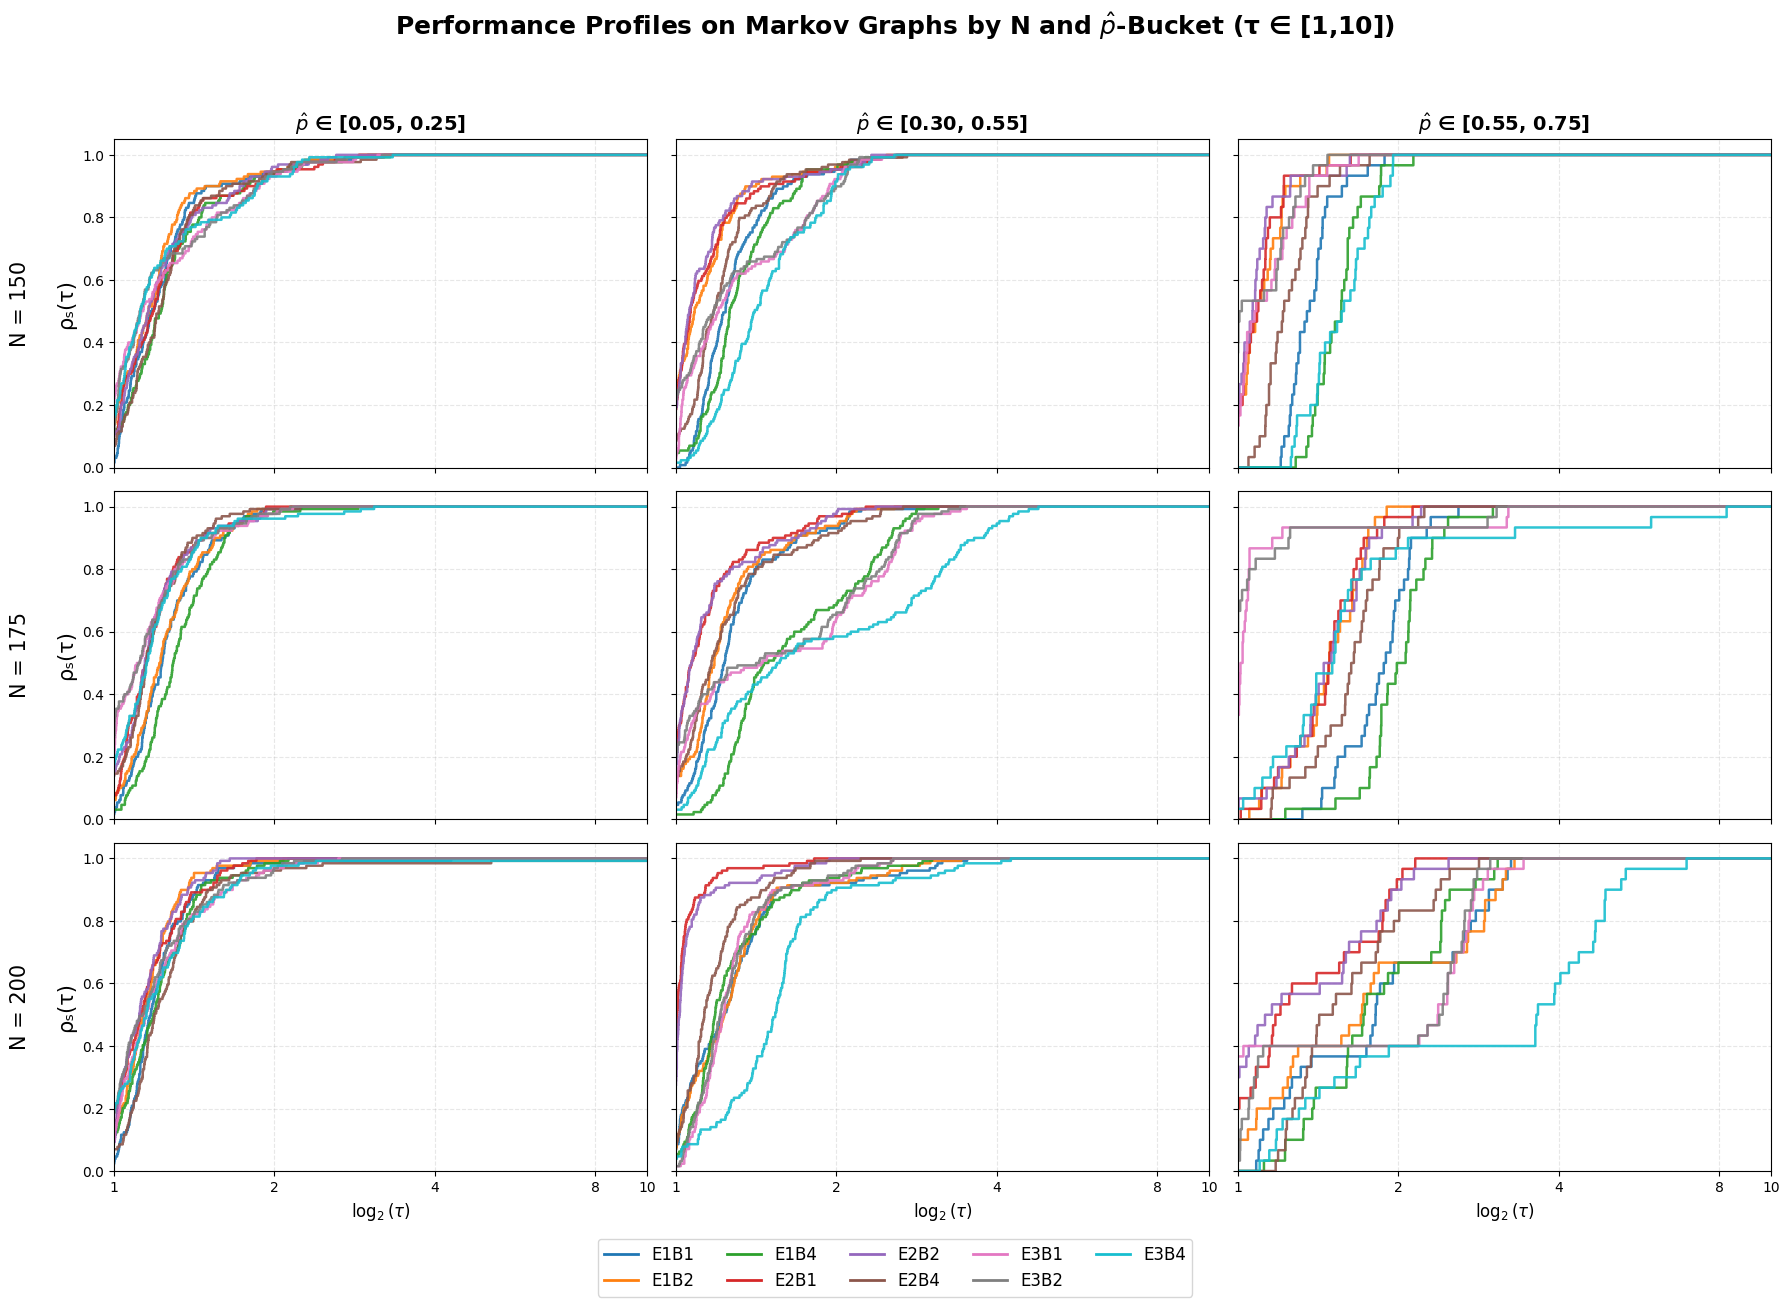

In [35]:
## Set Up, ensure the N_values match the coresponding N values from data set uploaded (does not work for DIMACS instances
## Set the p buckets as required
N_values = [150, 175, 200]

p_buckets = {
    r"$\hat{p}$ ∈ [0.05, 0.25]": (0.05, 0.25),
    r"$\hat{p}$ ∈ [0.30, 0.55]": (0.30, 0.50),
    r"$\hat{p}$ ∈ [0.55, 0.75]": (0.55, 0.75),
}


rel_cols = [
    col for col in df.columns
    if col.endswith("_solution_time_ratio")
]


solver_labels = [
    col.replace("_solution_time_ratio", "")
    for col in rel_cols
]

# ------------------------------------------------------------------
# Performance profile function (τ up to 10)
# ------------------------------------------------------------------
def performance_profile(ratios, tau_max=10.0, n_pts=2000):
    tau = np.logspace(0, np.log10(tau_max), n_pts)
    tau = np.insert(tau, 0, 1.0)
    rho = np.mean(ratios[:, :, np.newaxis] <= tau, axis=0)
    return tau, rho

# ------------------------------------------------------------------
# Create grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(N_values),
    ncols=len(p_buckets),
    figsize=(18, 66/5),
    sharex=True,
    sharey=True
)

for i, N in enumerate(N_values):
    for j, (bucket_label, (p_lo, p_hi)) in enumerate(p_buckets.items()):

        ax = axes[i, j]

        subset = df[
            (df["N"] == N) &
            (df["p_hat"] >= p_lo) &
            (df["p_hat"] <= p_hi)
        ]

        if subset.empty:
            ax.set_title(f"N={N}, {bucket_label}\n(no data)")
            ax.axis("off")
            continue

        ratios = (
            subset[rel_cols]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy()
        )

        # Remove invalid rows
        ratios = ratios[
            ~np.any(np.isnan(ratios), axis=1) &
            ~np.any(ratios <= 0, axis=1)
        ]

        if ratios.shape[0] == 0:
            ax.set_title(f"N={N}, {bucket_label}\n(no valid ratios)")
            ax.axis("off")
            continue

        tau, rho = performance_profile(ratios, tau_max=10)

        # Plot
        for k in range(len(rel_cols)):
            ax.step(
                np.log2(tau),
                rho[k, :],
                where="post",
                linewidth=1.8,
                color=colors[k % len(colors)],
                alpha=0.9
            )

        #Axis formatting (τ ∈ [1,10])
        ax.set_xlim(0, np.log2(10))
        ax.set_ylim(0, 1.05)

        tau_ticks = [1, 2, 4, 8, 10]
        ax.set_xticks([np.log2(t) for t in tau_ticks])
        ax.set_xticklabels([str(t) for t in tau_ticks])

        ax.grid(True, which="both", ls="--", alpha=0.3)

        # Titles
        if i == 0:
            ax.set_title(bucket_label, fontsize=14, fontweight="bold")

        if j == 0:
            ax.set_ylabel(f"N = {N}\n\nρₛ(τ)", fontsize=15)

        if i == len(N_values) - 1:
            ax.set_xlabel(r"$\log_2(\tau)$", fontsize=12)

# Legend set up 

handles = [
    plt.Line2D([0], [0], color=colors[i % len(colors)], lw=2,
               label=solver_labels[i])
    for i in range(len(rel_cols))
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=5,
    fontsize=12,
    frameon=True
)

fig.suptitle(
    r"Performance Profiles on Markov Graphs by N and $\hat{p}$-Bucket (τ ∈ [1,10])",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
# plt.savefig("Markov_Cperf_profiles_grid_by_N_pbucketmid_tau10_noE3B3.png",
#             dpi=300, bbox_inches="tight")
plt.show()

## Solution Time CDFs


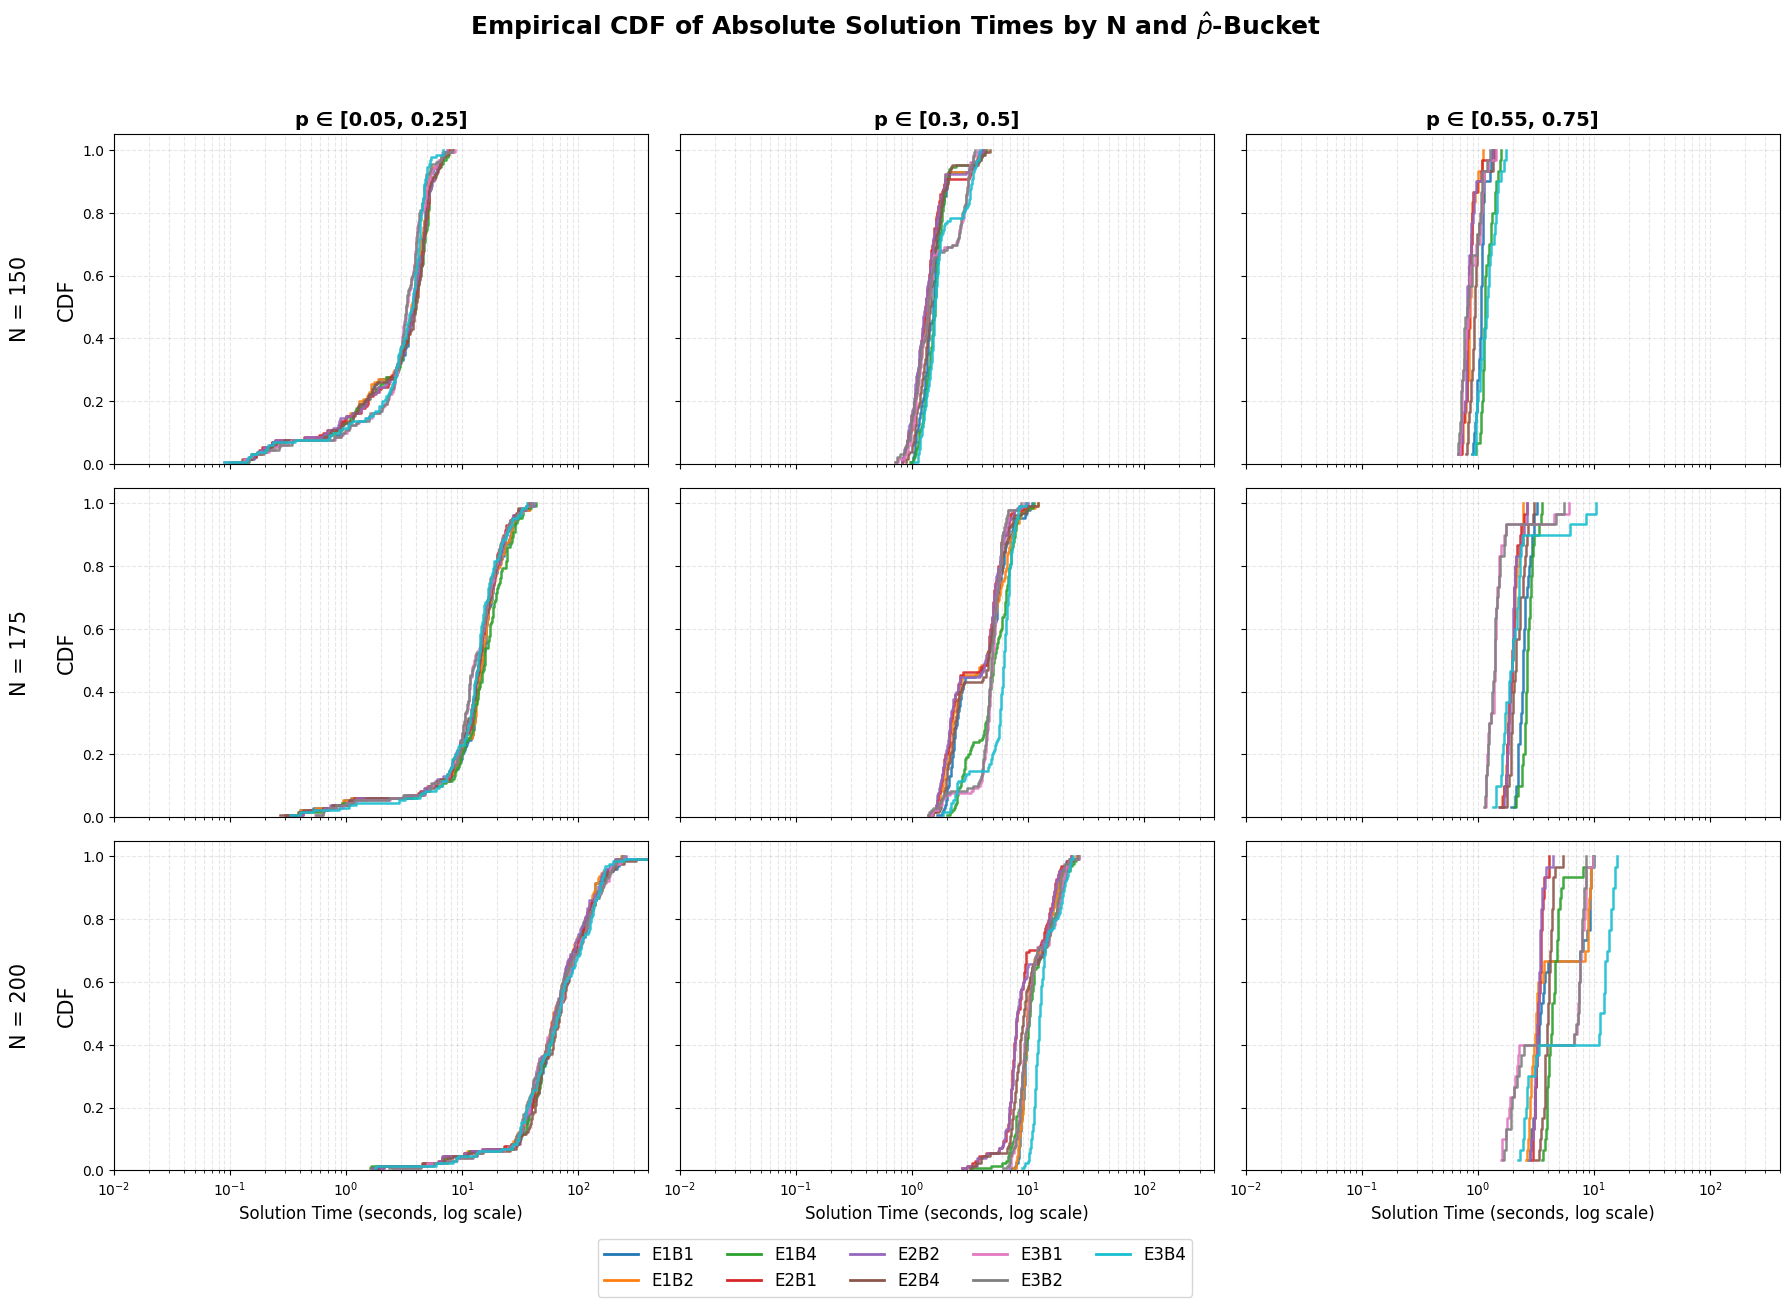

In [ ]:
## Set Up, ensure the N_values match the coresponding N values from data set uploaded (does not work for DIMACS instances
## Set the p_hat buckets as required
N_values = [150, 175, 200]

p_buckets = {
    "p ∈ [0.05, 0.25]": (0.05, 0.25),
    "p ∈ [0.3, 0.5]": (0.3, 0.5),
    "p ∈ [0.55, 0.75]": (0.55, 0.75),
}

# Detect time columns AND REMOVE E3B3

time_cols = [
    col for col in df.columns
    if col.endswith("_solution_times")
    and "E3B3" not in col
]

# Sort solvers (E1B1, E1B2, ..., E3B4)
def solver_sort_key(col):
    match = re.search(r"E(\d+)B(\d+)", col)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    return (999, 999)

time_cols = sorted(time_cols, key=solver_sort_key)

solver_labels = [
    col.replace("_solution_times", "")
    for col in time_cols
]


# Compute GLOBAL x-limits for log scale

all_times = (
    df[time_cols]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy()
    .flatten()
)

all_times = all_times[(~np.isnan(all_times)) & (all_times > 0)]

xmin = 1e-2   # 0.01
xmax = 4e2    # 400

# Create grid

fig, axes = plt.subplots(
    nrows=len(N_values),
    ncols=len(p_buckets),
    figsize=(18, 66/5),
    sharex=True,
    sharey=True
)

for i, N in enumerate(N_values):
    for j, (bucket_label, (p_lo, p_hi)) in enumerate(p_buckets.items()):

        ax = axes[i, j]

        subset = df[
            (df["N"] == N) &
            (df["p_hat"] >= p_lo) &
            (df["p_hat"] <= p_hi)
        ]

        if subset.empty:
            ax.set_title(f"N={N}, {bucket_label}\n(no data)")
            ax.axis("off")
            continue

        times = (
            subset[time_cols]
            .apply(pd.to_numeric, errors="coerce")
        )

        #¢ Plot ECDF for each solver
        for k, col in enumerate(time_cols):

            t = times[col].dropna()
            t = t[t > 0]

            if len(t) == 0:
                continue

            t_sorted = np.sort(t)
            y = np.arange(1, len(t_sorted) + 1) / len(t_sorted)

            ax.step(
                t_sorted,
                y,
                where="post",
                linewidth=1.8,
                color=colors[k % len(colors)],
                alpha=0.9
            )

        #axis formatting
        ax.set_xscale("log")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0, 1.05)

        ax.grid(True, which="both", ls="--", alpha=0.3)

        # titles
        if i == 0:
            ax.set_title(bucket_label, fontsize=14, fontweight="bold")

        if j == 0:
            ax.set_ylabel(f"N = {N}\n\nCDF", fontsize=15)

        if i == len(N_values) - 1:
            ax.set_xlabel("Solution Time (seconds, log scale)", fontsize=12)


# Create appropriate legend

handles = [
    plt.Line2D([0], [0], color=colors[i % len(colors)], lw=2,
               label=solver_labels[i])
    for i in range(len(time_cols))
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=5,
    fontsize=12,
    frameon=True
)

fig.suptitle(
    r"Empirical CDF of Absolute Solution Times by N and $\hat{p}$-Bucket",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
# plt.savefig(
#     "Markov_absolute_time_cdf_grid_by_N_pbucket_logscale_noE3B3.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()